# 🐼 Lab 4: Pandas — Data Analysis and Manipulation
### DATA.110 - Introduction to Python Programming for Machine Learning
---
**Objective:** Use Pandas for loading, exploring, cleaning, transforming, and visualizing tabular data.

**Topics Covered:**
- Series and DataFrame fundamentals
- Reading data (CSV, dict)
- Exploring data (head, info, describe)
- Indexing and filtering
- Handling missing values
- Data transformation and feature engineering
- Groupby and aggregation
- Merging and joining DataFrames
- Visualization with Pandas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(f"Pandas version: {pd.__version__}")
print(f"NumPy version:  {np.__version__}")

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

Pandas version: 2.3.3
NumPy version:  2.3.5


## 1. Pandas Series
A `Series` is a 1D labeled array — like a column in a spreadsheet.

In [2]:
# Creating Series
grades = pd.Series([88, 92, 79, 95, 83], 
                   index=['Alice','Bob','Carol','Dave','Eve'],
                   name='Midterm Scores')
print("Series:")
print(grades)
print(f"\nDtype: {grades.dtype}")
print(f"Mean:  {grades.mean():.2f}")
print(f"Std:   {grades.std():.2f}")

# Accessing elements
print("\nAlice's score:", grades['Alice'])
print("Top scorers:\n", grades[grades > 88])

# Series arithmetic
bonus = pd.Series({'Alice':2, 'Bob':5, 'Carol':0, 'Dave':3, 'Eve':1})
final = grades + bonus
print("\nFinal scores (with bonus):\n", final)

Series:
Alice    88
Bob      92
Carol    79
Dave     95
Eve      83
Name: Midterm Scores, dtype: int64

Dtype: int64
Mean:  87.40
Std:   6.50

Alice's score: 88
Top scorers:
 Bob     92
Dave    95
Name: Midterm Scores, dtype: int64

Final scores (with bonus):
 Alice    90
Bob      97
Carol    79
Dave     98
Eve      84
dtype: int64


## 2. Pandas DataFrame
A `DataFrame` is a 2D labeled data structure — the primary Pandas object.

In [3]:
# Create DataFrame from dictionary
np.random.seed(42)

data = {
    'Name':       ['Alice','Bob','Carol','Dave','Eve','Frank','Grace','Henry'],
    'Age':        [22, 25, 23, 28, 21, 26, 24, 27],
    'Major':      ['CS','Math','CS','Physics','Biology','Math','CS','Physics'],
    'GPA':        [3.85, 3.42, 3.91, 3.67, 3.28, 3.55, 3.78, 3.44],
    'Exam1':      [88, 74, 95, 82, 69, 78, 91, 76],
    'Exam2':      [92, 68, 98, 79, 73, 82, 87, 71],
    'Attendance': [95, 78, 99, 88, 72, 85, 93, 81],
    'Passed':     [True, True, True, True, False, True, True, True]
}

df = pd.DataFrame(data)
print("DataFrame:")
df

DataFrame:


,Name,Age,Major,GPA,Exam1,Exam2,Attendance,Passed
0,Alice,22,CS,3.85,88,92,95,True
1,Bob,25,Math,3.42,74,68,78,True
2,Carol,23,CS,3.91,95,98,99,True
3,Dave,28,Physics,3.67,82,79,88,True
4,Eve,21,Biology,3.28,69,73,72,False
5,Frank,26,Math,3.55,78,82,85,True
6,Grace,24,CS,3.78,91,87,93,True
7,Henry,27,Physics,3.44,76,71,81,True


## 3. Exploring a DataFrame

In [4]:
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Shape: (8, 8)

Column names: ['Name', 'Age', 'Major', 'GPA', 'Exam1', 'Exam2', 'Attendance', 'Passed']

Data types:
Name           object
Age             int64
Major          object
GPA           float64
Exam1           int64
Exam2           int64
Attendance      int64
Passed           bool
dtype: object


In [5]:
print("Head (first 3 rows):")
display(df.head(3))

print("\nTail (last 2 rows):")
display(df.tail(2))

Head (first 3 rows):


,Name,Age,Major,GPA,Exam1,Exam2,Attendance,Passed
0,Alice,22,CS,3.85,88,92,95,True
1,Bob,25,Math,3.42,74,68,78,True
2,Carol,23,CS,3.91,95,98,99,True



Tail (last 2 rows):


,Name,Age,Major,GPA,Exam1,Exam2,Attendance,Passed
6,Grace,24,CS,3.78,91,87,93,True
7,Henry,27,Physics,3.44,76,71,81,True


In [6]:
print("Statistical Summary:")
df.describe()

Statistical Summary:


,Age,GPA,Exam1,Exam2,Attendance
count,8.00000,8.000000,8.000000,8.00000,8.000000
mean,24.50000,3.612500,81.625000,81.25000,86.375000
std,2.44949,0.226006,9.022789,10.57963,9.164177
min,21.00000,3.280000,69.000000,68.00000,72.000000
25%,22.75000,3.435000,75.500000,72.50000,80.250000
50%,24.50000,3.610000,80.000000,80.50000,86.500000
75%,26.25000,3.797500,88.750000,88.25000,93.500000
max,28.00000,3.910000,95.000000,98.00000,99.000000


In [7]:
print("Info:")
df.info()

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        8 non-null      object 
 1   Age         8 non-null      int64  
 2   Major       8 non-null      object 
 3   GPA         8 non-null      float64
 4   Exam1       8 non-null      int64  
 5   Exam2       8 non-null      int64  
 6   Attendance  8 non-null      int64  
 7   Passed      8 non-null      bool   
dtypes: bool(1), float64(1), int64(4), object(2)
memory usage: 588.0+ bytes


## 4. Indexing and Filtering

In [8]:
# Select single column
print("GPA column:")
print(df['GPA'])

# Select multiple columns
print("\nName and Major:")
print(df[['Name', 'Major']])

GPA column:
0    3.85
1    3.42
2    3.91
3    3.67
4    3.28
5    3.55
6    3.78
7    3.44
Name: GPA, dtype: float64

Name and Major:
    Name    Major
0  Alice       CS
1    Bob     Math
2  Carol       CS
3   Dave  Physics
4    Eve  Biology
5  Frank     Math
6  Grace       CS
7  Henry  Physics


In [9]:
# .loc — label-based
print(".loc[0] (first row):")
print(df.loc[0])

print("\n.loc[2:4, ['Name','GPA','Passed']]:")
print(df.loc[2:4, ['Name','GPA','Passed']])

# .iloc — position-based
print("\n.iloc[0:3, 0:4]:")
print(df.iloc[0:3, 0:4])

.loc[0] (first row):
Name          Alice
Age              22
Major            CS
GPA            3.85
Exam1            88
Exam2            92
Attendance       95
Passed         True
Name: 0, dtype: object

.loc[2:4, ['Name','GPA','Passed']]:
    Name   GPA  Passed
2  Carol  3.91    True
3   Dave  3.67    True
4    Eve  3.28   False

.iloc[0:3, 0:4]:
    Name  Age Major   GPA
0  Alice   22    CS  3.85
1    Bob   25  Math  3.42
2  Carol   23    CS  3.91


In [10]:
# Boolean filtering
print("CS students with GPA > 3.8:")
mask = (df['Major'] == 'CS') & (df['GPA'] > 3.8)
print(df[mask][['Name','Major','GPA']])

print("\nStudents who failed or had attendance < 80%:")
low_perf = (~df['Passed']) | (df['Attendance'] < 80)
print(df[low_perf][['Name','Passed','Attendance']])

# isin()
print("\nSTEM majors (CS or Physics):")
stem = df[df['Major'].isin(['CS','Physics'])]
print(stem[['Name','Major','GPA']])

CS students with GPA > 3.8:
    Name Major   GPA
0  Alice    CS  3.85
2  Carol    CS  3.91

Students who failed or had attendance < 80%:
  Name  Passed  Attendance
1  Bob    True          78
4  Eve   False          72

STEM majors (CS or Physics):
    Name    Major   GPA
0  Alice       CS  3.85
2  Carol       CS  3.91
3   Dave  Physics  3.67
6  Grace       CS  3.78
7  Henry  Physics  3.44


## 5. Handling Missing Values

In [11]:
# Create DataFrame with NaNs
df_missing = df.copy()
np.random.seed(10)
mask = np.random.choice([True, False], size=df.shape, p=[0.15, 0.85])
df_missing = df_missing.where(~mask)
df_missing.loc[:, 'Name'] = df['Name']  # keep Names intact

print("Missing values per column:")
print(df_missing.isnull().sum())

print(f"\nTotal missing: {df_missing.isnull().sum().sum()}")
print(f"Missing %: {df_missing.isnull().mean().mul(100).round(1).to_dict()}")

Missing values per column:
Name          0
Age           2
Major         1
GPA           1
Exam1         2
Exam2         1
Attendance    1
Passed        0
dtype: int64

Total missing: 8
Missing %: {'Name': 0.0, 'Age': 25.0, 'Major': 12.5, 'GPA': 12.5, 'Exam1': 25.0, 'Exam2': 12.5, 'Attendance': 12.5, 'Passed': 0.0}


In [12]:
# Drop rows with any missing values
df_dropped = df_missing.dropna()
print(f"Rows after dropna(): {len(df_dropped)} / {len(df_missing)}")

# Fill missing values
df_filled = df_missing.copy()
numeric_cols = df_filled.select_dtypes(include=np.number).columns

# Fill numeric with median
for col in numeric_cols:
    median = df_filled[col].median()
    df_filled[col] = df_filled[col].fillna(median)

# Fill categorical with mode
df_filled['Major'] = df_filled['Major'].fillna(df_filled['Major'].mode()[0])
df_filled['Passed'] = df_filled['Passed'].fillna(True)

print("Missing after filling:", df_filled.isnull().sum().sum())
print("\nFilled DataFrame:")
print(df_filled)

Rows after dropna(): 3 / 8
Missing after filling: 0

Filled DataFrame:
    Name   Age    Major   GPA  Exam1  Exam2  Attendance  Passed
0  Alice  25.0       CS  3.85   88.0   92.0        95.0    True
1    Bob  25.0     Math  3.42   85.0   68.0        78.0    True
2  Carol  23.0       CS  3.91   95.0   79.0        99.0    True
3   Dave  28.0  Physics  3.67   82.0   79.0        88.0    True
4    Eve  21.0       CS  3.28   85.0   73.0        88.0   False
5  Frank  26.0     Math  3.55   78.0   82.0        85.0    True
6  Grace  24.0       CS  3.55   91.0   87.0        93.0    True
7  Henry  27.0  Physics  3.44   76.0   71.0        81.0    True


## 6. Data Transformation and Feature Engineering

In [13]:
# Adding new columns
df2 = df.copy()

# Calculated column
df2['AvgExam'] = (df2['Exam1'] + df2['Exam2']) / 2

# apply() with lambda
df2['Grade'] = df2['AvgExam'].apply(lambda x:
    'A' if x >= 90 else 'B' if x >= 80 else 'C' if x >= 70 else 'D')

# String operations
df2['Name_Upper'] = df2['Name'].str.upper()
df2['Name_Len']   = df2['Name'].str.len()

# Cut — bin continuous into categories
df2['GPA_Band'] = pd.cut(df2['GPA'], 
                          bins=[0, 3.0, 3.5, 3.7, 4.0],
                          labels=['Below 3.0','3.0–3.5','3.5–3.7','3.7+'])

print(df2[['Name','AvgExam','Grade','GPA','GPA_Band']].to_string())

    Name  AvgExam Grade   GPA GPA_Band
0  Alice     90.0     A  3.85     3.7+
1    Bob     71.0     C  3.42  3.0–3.5
2  Carol     96.5     A  3.91     3.7+
3   Dave     80.5     B  3.67  3.5–3.7
4    Eve     71.0     C  3.28  3.0–3.5
5  Frank     80.0     B  3.55  3.5–3.7
6  Grace     89.0     B  3.78     3.7+
7  Henry     73.5     C  3.44  3.0–3.5


In [14]:
# Sorting
print("Top 5 by GPA:")
print(df2.sort_values('GPA', ascending=False).head(5)[['Name','Major','GPA','Grade']])

# Renaming columns
df2.rename(columns={'Exam1':'Quiz1','Exam2':'Quiz2'}, inplace=True)
print("\nColumns after rename:", df2.columns.tolist())

Top 5 by GPA:
    Name    Major   GPA Grade
2  Carol       CS  3.91     A
0  Alice       CS  3.85     A
6  Grace       CS  3.78     B
3   Dave  Physics  3.67     B
5  Frank     Math  3.55     B

Columns after rename: ['Name', 'Age', 'Major', 'GPA', 'Quiz1', 'Quiz2', 'Attendance', 'Passed', 'AvgExam', 'Grade', 'Name_Upper', 'Name_Len', 'GPA_Band']


## 7. GroupBy and Aggregation

In [15]:
# groupby().agg()
group_stats = df.groupby('Major').agg(
    Count     = ('Name',  'count'),
    Avg_GPA   = ('GPA',   'mean'),
    Avg_Exam1 = ('Exam1', 'mean'),
    Avg_Exam2 = ('Exam2', 'mean'),
    Avg_Attend= ('Attendance', 'mean')
).round(2)

print("Statistics by Major:")
print(group_stats)

# Multiple aggregation functions
print("\nGPA stats by Major:")
print(df.groupby('Major')['GPA'].agg(['min','mean','max','std']).round(3))

Statistics by Major:
         Count  Avg_GPA  Avg_Exam1  Avg_Exam2  Avg_Attend
Major                                                    
Biology      1     3.28      69.00      73.00       72.00
CS           3     3.85      91.33      92.33       95.67
Math         2     3.48      76.00      75.00       81.50
Physics      2     3.56      79.00      75.00       84.50

GPA stats by Major:
          min   mean   max    std
Major                            
Biology  3.28  3.280  3.28    NaN
CS       3.78  3.847  3.91  0.065
Math     3.42  3.485  3.55  0.092
Physics  3.44  3.555  3.67  0.163


In [16]:
# value_counts
print("Major distribution:")
print(df['Major'].value_counts())

print("\nPassed distribution:")
print(df['Passed'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Major distribution:
Major
CS         3
Math       2
Physics    2
Biology    1
Name: count, dtype: int64

Passed distribution:
Passed
True     87.5%
False    12.5%
Name: proportion, dtype: object


## 8. Merging DataFrames

In [17]:
# Create two DataFrames to join
students = pd.DataFrame({
    'StudentID': [101, 102, 103, 104, 105],
    'Name':      ['Alice','Bob','Carol','Dave','Eve'],
    'Major':     ['CS','Math','CS','Physics','Biology']
})

scores_df = pd.DataFrame({
    'StudentID': [101, 102, 103, 106, 107],   # 106, 107 not in students
    'Midterm':   [88, 74, 95, 82, 66],
    'Final':     [91, 78, 97, 85, 70]
})

print("Students:")
print(students)
print("\nScores:")
print(scores_df)

# Inner join
inner = pd.merge(students, scores_df, on='StudentID', how='inner')
print("\nInner join:")
print(inner)

# Left join
left = pd.merge(students, scores_df, on='StudentID', how='left')
print("\nLeft join (keeps all students):")
print(left)

Students:
   StudentID   Name    Major
0        101  Alice       CS
1        102    Bob     Math
2        103  Carol       CS
3        104   Dave  Physics
4        105    Eve  Biology

Scores:
   StudentID  Midterm  Final
0        101       88     91
1        102       74     78
2        103       95     97
3        106       82     85
4        107       66     70

Inner join:
   StudentID   Name Major  Midterm  Final
0        101  Alice    CS       88     91
1        102    Bob  Math       74     78
2        103  Carol    CS       95     97

Left join (keeps all students):
   StudentID   Name    Major  Midterm  Final
0        101  Alice       CS     88.0   91.0
1        102    Bob     Math     74.0   78.0
2        103  Carol       CS     95.0   97.0
3        104   Dave  Physics      NaN    NaN
4        105    Eve  Biology      NaN    NaN


## 9. Visualization with Pandas

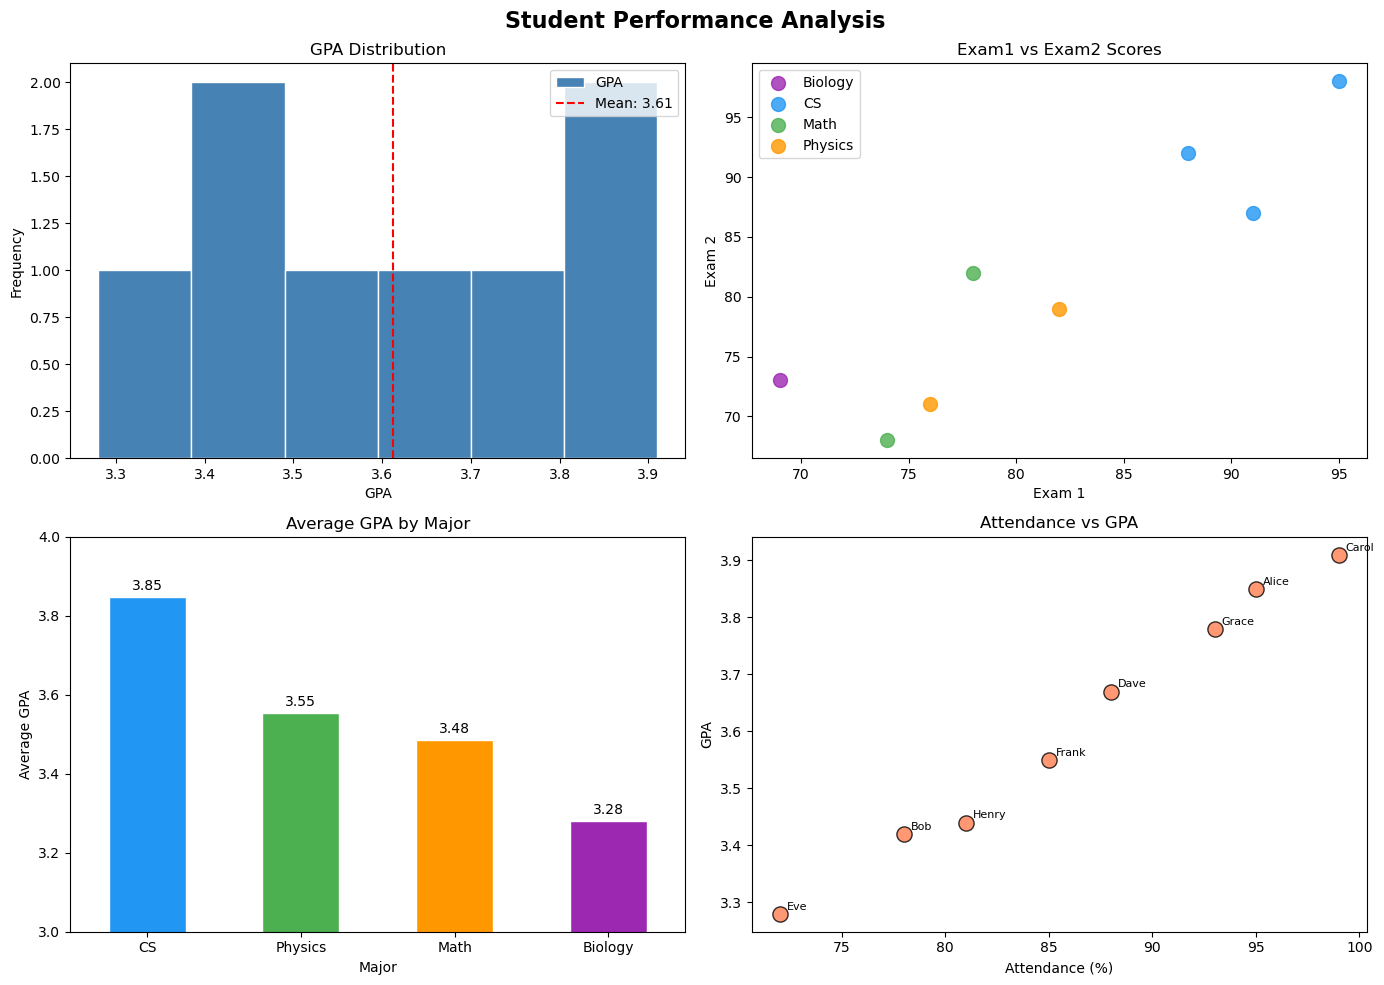

Figure saved.


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Student Performance Analysis', fontsize=16, fontweight='bold')

# 1. GPA distribution (histogram)
df['GPA'].plot(kind='hist', bins=6, ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('GPA Distribution')
axes[0,0].set_xlabel('GPA')
axes[0,0].set_ylabel('Frequency')
axes[0,0].axvline(df['GPA'].mean(), color='red', linestyle='--', label=f'Mean: {df["GPA"].mean():.2f}')
axes[0,0].legend()

# 2. Exam 1 vs Exam 2 (scatter)
colors_map = {'CS':'#2196F3', 'Math':'#4CAF50', 'Physics':'#FF9800', 'Biology':'#9C27B0'}
for major, grp in df.groupby('Major'):
    axes[0,1].scatter(grp['Exam1'], grp['Exam2'], label=major, 
                      color=colors_map[major], s=100, alpha=0.8)
axes[0,1].set_title('Exam1 vs Exam2 Scores')
axes[0,1].set_xlabel('Exam 1')
axes[0,1].set_ylabel('Exam 2')
axes[0,1].legend()

# 3. Average GPA by Major (bar)
gpa_by_major = df.groupby('Major')['GPA'].mean().sort_values(ascending=False)
gpa_by_major.plot(kind='bar', ax=axes[1,0], color=['#2196F3','#4CAF50','#FF9800','#9C27B0'],
                  edgecolor='white', rot=0)
axes[1,0].set_title('Average GPA by Major')
axes[1,0].set_xlabel('Major')
axes[1,0].set_ylabel('Average GPA')
axes[1,0].set_ylim(3.0, 4.0)
for bar in axes[1,0].patches:
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.01, f'{bar.get_height():.2f}',
                   ha='center', va='bottom', fontsize=10)

# 4. GPA vs Attendance (scatter)
axes[1,1].scatter(df['Attendance'], df['GPA'], c='coral', s=120, alpha=0.8, edgecolors='black')
for _, row in df.iterrows():
    axes[1,1].annotate(row['Name'], (row['Attendance'], row['GPA']),
                       textcoords='offset points', xytext=(5,3), fontsize=8)
axes[1,1].set_title('Attendance vs GPA')
axes[1,1].set_xlabel('Attendance (%)')
axes[1,1].set_ylabel('GPA')

plt.tight_layout()
plt.savefig('student_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure saved.")

## 10. Pivot Tables

In [19]:
# Larger dataset for pivot table demo
np.random.seed(7)
n = 50
big = pd.DataFrame({
    'Major':  np.random.choice(['CS','Math','Physics','Biology'], n),
    'Year':   np.random.choice([1,2,3,4], n),
    'Gender': np.random.choice(['M','F'], n),
    'GPA':    np.round(np.random.normal(3.5, 0.3, n).clip(2.0, 4.0), 2)
})

pivot = big.pivot_table(values='GPA', index='Major', columns='Year', aggfunc='mean').round(2)
print("Average GPA by Major and Year:")
print(pivot)

Average GPA by Major and Year:
Year        1     2     3     4
Major                          
Biology  3.14  3.12  3.93  3.50
CS       3.56  3.38  3.64  3.54
Math     3.56  3.34   NaN  3.51
Physics  3.72  3.48  2.69  3.21


## Summary

| Task | Pandas Method |
|---|---|
| Create DataFrame | `pd.DataFrame(dict)` |
| Inspect | `.head()`, `.info()`, `.describe()`, `.shape` |
| Select columns | `df['col']`, `df[['a','b']]` |
| Label indexing | `.loc[row, col]` |
| Position indexing | `.iloc[r, c]` |
| Filter rows | `df[df['col'] > val]` |
| Missing values | `.isnull()`, `.dropna()`, `.fillna()` |
| Add column | `df['new'] = ...` |
| Apply function | `.apply(func)` |
| Group & aggregate | `.groupby().agg()` |
| Merge DataFrames | `pd.merge()` |
| Pivot table | `pd.pivot_table()` |

---
✅ **Lab 4 Complete**